# Online Retail II Data Set
**Descrição:** Esse conjunto de dados contém todas as transações de uma empresa de varejo online no Reino Unido entre 01/12/2009 e 09/12/2011. Essa companhia vende artigos de presentes para todas as ocasiões. Vários clientes são revendedores.

**Disponível em:** [10.24432/C5CG6D](https://doi.org/10.24432/C5CG6D)

**Objetivo do projeto:** Fazer uma análise de segmentação de clientes a partir de uma análise de clustering (KMeans) e propor ações estratégicas para tomar com cada grupo.

**Descrição dos dados:**

| Variável | Descrição |
| :------: | :-------: |
| Invoice  | Código de 6 digitos atribuído unicamente para cada transação. Se o código começar com a letra C, indica um cancelamento|
| StockCode | Código de 5 dígitos atribuído unicamente para cada produto |
| Description | Nome do produto |
| Quantity | Quantidade de cada produto por transação |
| InvoiceDate | Data e hora que a transação foi gerada |
| UnitPrice | Preço da unidade do produto |
| Customer ID | Código de 5 digitos atribuído unicamente para cada cliente |
| Country | País onde o cliente reside |


Importando as bibliotecas necessárias

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.options.display.float_format = "{:20.2f}".format
pd.set_option("display.max_columns", 999)

## Limpeza do conjunto de dados
### Objetivos
- Verificar inconsistências nas entradas dos dados
- Limpar os dados para garantir consistência de análise

**Carregando o conjunto de dados e visualizando as primeiras entradas**

In [3]:
todas_as_planilhas = pd.read_excel("data/online_retail_II.xlsx", sheet_name=None)
df = pd.concat(todas_as_planilhas.values(), ignore_index=True)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


As variáveis "Customer ID", "Invoice", "StockCode" e "Description" foram lidas como float64 ou object, transformá-las em variáveis do tipo str vai facilitar a análise de cada uma dessas colunas.

In [5]:
# Trocamos o tipo das variáveis nominais para str
df["Customer ID"] = df["Customer ID"].astype("str")
df["Invoice"] = df["Invoice"].astype("str")
df["StockCode"] = df["StockCode"].astype("str")

# Análise descritiva das variáveis nominais
df.describe(include=["O", "str"])

,Invoice,StockCode,Description,Customer ID,Country
count,1067371,1067371,1062989,824364,1067371
unique,53628,5305,5698,5942,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17841.0,United Kingdom
freq,1350,5829,5918,13097,981330


Também é importante verificar a existência de registros duplicados na base de dados, pois duplicações indevidas podem superestimar a frequência de compra e o valor monetário associado a determinados clientes, distorcendo os resultados da segmentação.

In [6]:
# Verificando entradas duplicadas
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


As entradas duplicadas serão excluídas do conjunto analisado, pois não representam transações reais dos clientes

In [7]:
# Removendo entradas duplicadas do dataframe
df.drop_duplicates(inplace=True)

**Análise das variáveis nominais**

Análise da variável **Customer ID**
- São esperados códigos únicos de 6 digitos para cada cliente

In [8]:
df[~(df["Customer ID"].str.match(r"^\d{1,6}"))]["Customer ID"].unique()

<ArrowStringArray>
[nan]
Length: 1, dtype: str

A variável Customer ID tem valores faltando (nan), mas não tem códigos que fogem ao padrão descrito na documentação da base. 

In [9]:
no_id_df = df[(df["Customer ID"].isnull())]
print(f"{len(no_id_df)} entradas não indicam o ID do cliente, isso representa um total de {len(no_id_df)/len(df)*100:.2f}%")

235151 entradas não indicam o ID do cliente, isso representa um total de 22.76%


Aproximadamente 23% das entradas não tem um ID de cliente registrado. Como este projeto busca fazer uma classificação dos clientes em grupos e não é possível atribuir uma transação não identificada a um cliente, iremos excluir esses dados da análise

In [10]:
# Criamos um novo dataframe que vamos limpar
clean_df = df.copy()

# Retiramos as entradas sem identificação do cliente
clean_df.dropna(subset=["Customer ID"], inplace=True)

clean_df.info()

<class 'pandas.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  str           
 1   StockCode    797885 non-null  str           
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[us]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  str           
 7   Country      797885 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(1), str(4)
memory usage: 79.0+ MB


Análise da variável **Invoice**
- Espera-se que sejam números de 6 dígitos únicos para cada transação
- Se o código for precedido da letra "C", indica um cancelamento

In [11]:
clean_df[clean_df["Invoice"].str.match(r"^\d{6}$") == False].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [12]:
clean_df["Invoice"].str.replace(r"[0-9]", "", regex=True).unique()

<ArrowStringArray>
['', 'C']
Length: 2, dtype: str

Não encontramos inconsistências na coluna Invoice do conjunto limpo.

Para a análise de segmentação de clientes proposta, podemos excluir as entradas referentes à cancelamentos (prefixo C).

In [13]:
canceladas_df = clean_df[clean_df["Invoice"].str.match(r"^C\d{6}")]
clean_df.drop(index=canceladas_df.index, inplace=True)

Análise da variável **StockCode**
- São esperados códigos numéricos de 5 dígitos únicos para cada tipo de produto

In [14]:
clean_df[(clean_df["StockCode"].str.match(r"^\d{5}$") == False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.0,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067270,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
1067302,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
1067308,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom
1067317,581580,85049E,SCANDINAVIAN REDS RIBBONS,2,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


Existem transações em que o StockCode não segue o padrão descrito na documentação da base, mas como o resto dos dados das transações estão ok, eu vou tratar elas como transações válidas.

Foi constatado que existem outros tipos de entrada que não seguem um padrão numérico, precisamos verificá-las.

In [15]:
clean_df[(clean_df["StockCode"].str.match(r"^\d{5}$") == False) & (clean_df["StockCode"].str.match(r"^\d{5}[a-zA-Z]")==False)]["StockCode"].unique()

<ArrowStringArray>
[        'POST',           'C2',            'M', 'BANK CHARGES',
      'TEST001',      'TEST002',         'PADS',       'ADJUST',
            'D',      'ADJUST2',       'SP1002',          'DOT']
Length: 12, dtype: str

In [16]:
# Analisamos cada código individualmente
clean_df[clean_df["StockCode"].str.contains(r"^C2")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.00,14156.0,EIRE
14502,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.00,14911.0,EIRE
19541,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.00,16253.0,United Kingdom
22803,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.00,14911.0,EIRE
32964,492092,C2,CARRIAGE,1,2009-12-15 14:03:00,50.00,14156.0,EIRE
...,...,...,...,...,...,...,...,...
1038663,579539,C2,CARRIAGE,1,2011-11-30 10:06:00,50.00,14911.0,EIRE
1040462,579768,C2,CARRIAGE,1,2011-11-30 15:08:00,50.00,14911.0,EIRE
1041945,579910,C2,CARRIAGE,1,2011-12-01 08:52:00,50.00,14911.0,EIRE
1044366,580127,C2,CARRIAGE,1,2011-12-01 17:51:00,50.00,14911.0,EIRE


Existem 12 códigos StockCode que não seguem o padrão descrito na documentação. Para avaliar se vou usá-los ou não, vou verificar um a um e definir sua importância

| Código | Descrição | Decisão |
| :----: | :-------: | :-----: |
|  POST  |  Taxas de envio | Excluir da análise |
| D | Descontos aplicados | Excluir da análise |
| M | Representam transações manuais e parecem válidas | Manter na análise |
| C2 | Transações de transporte - Não sei exatamente o que significam | Excluir da análise |
| BANK CHARGES | Taxas de banco das transações | Excluir da análise |
| TESTXXX| Transações de teste | Excluir da análise |
| PADS | Código para enchimentos de almofadas e transações ok | Manter na análise |
| ADJUSTX | Ajustes manuais da base por admins | Excluir da análise |
| SP1002 | Código de quadros brancos pequenos para criança e transações ok | Manter na análise |
| DOT | Taxas de envio | Excluir da análise |



In [17]:
excluir = ["D", "C2", "BANK CHARGES", "TEST001", "TEST002", "ADJUST", "ADJUST2", "SP1002", "DOT", "CRUK", "POST"]

clean_df = clean_df[~clean_df["StockCode"].isin(excluir)]

Análise da variável **Country**
- Esperamos que sejam referentes ao país de origem do cliente

In [18]:
df["Country"].unique()

<ArrowStringArray>
[      'United Kingdom',               'France',                  'USA',
              'Belgium',            'Australia',                 'EIRE',
              'Germany',             'Portugal',                'Japan',
              'Denmark',              'Nigeria',          'Netherlands',
               'Poland',                'Spain',      'Channel Islands',
                'Italy',               'Cyprus',               'Greece',
               'Norway',              'Austria',               'Sweden',
 'United Arab Emirates',              'Finland',          'Switzerland',
          'Unspecified',                'Malta',              'Bahrain',
                  'RSA',              'Bermuda',            'Hong Kong',
            'Singapore',             'Thailand',               'Israel',
            'Lithuania',          'West Indies',              'Lebanon',
                'Korea',               'Brazil',               'Canada',
              'Iceland',        

Não encontramos incosistências na coluna Country

**Análise das colunas numéricas**

Para analisar as colunas numéricas começamos fazendo uma breve análise descritiva delas

In [19]:
clean_df.describe()

,Quantity,InvoiceDate,Price
count,777343.00,777343,777343.00
mean,13.54,2011-01-02 23:45:22.067477,3.12
min,1.00,2009-12-01 07:45:00,0.00
25%,2.00,2010-07-02 14:15:00,1.25
50%,6.00,2010-12-02 13:32:00,1.95
75%,12.00,2011-08-01 13:11:00,3.75
max,80995.00,2011-12-09 12:50:00,10953.50
std,146.74,NaN,27.82


Analisando rapidamente os resultados, as colunas "Quantity" e "InvoiceDate" não parecem ter inconsistências. Já a coluna "Prices" tem o preço mínimo de 0.00, vamos verificar

In [20]:
clean_df[clean_df["Price"] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.00,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.00,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.00,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.00,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.00,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.00,15602.0,United Kingdom
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.00,12603.0,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.00,12444.0,Norway
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.00,16406.0,United Kingdom


São 68 entradas em que o preço consta como 0, como é um número muito pequeno de entradas comparado com o tamanho da base, vamos excluir esses dados da análise

In [21]:
clean_df = clean_df[clean_df["Price"] > 0]
clean_df.info()

<class 'pandas.DataFrame'>
Index: 777275 entries, 0 to 1067369
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      777275 non-null  str           
 1   StockCode    777275 non-null  str           
 2   Description  777275 non-null  object        
 3   Quantity     777275 non-null  int64         
 4   InvoiceDate  777275 non-null  datetime64[us]
 5   Price        777275 non-null  float64       
 6   Customer ID  777275 non-null  str           
 7   Country      777275 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(1), str(4)
memory usage: 77.0+ MB


Assim, terminamos a limpeza dos dados e podemos seguir para as próximas etapas.

## Feature Engineering 
Tradionalmente, análises de segmentação de clientes são feitas com base no modelo RFM (Recência, Frequência e Valor Monetário)
- Recência: Tempo (em dias) desde a última compra;
- Frequência: Número de vezes que o cliente compra durante o período de tempo analisado;
- Valor Monetário: Valor total gasto pelo cliente na loja.

O próximo passo para a análise é criar os fatores que iremos usar na análise.

In [22]:
# Criando o total de cada venda para calcular o Valor Monetário de cada cliente depois
clean_df["SaleTotalPrice"] = clean_df["Price"] * clean_df["Quantity"]

clean_df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SaleTotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.50
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.60
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.00


In [23]:
# Criando um dataframe novo com a variável "Customer ID" como índice e os fatores de interesse
aggregated_df = clean_df.groupby("Customer ID", as_index=False)\
    .agg(
        MonetaryValue = ("SaleTotalPrice", "sum"),
        Frequency = ("Invoice", "nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
)

aggregated_df.head(10)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,77352.96,3,2011-01-18 10:01:00
1,12347.0,4921.53,8,2011-12-07 15:52:00
2,12348.0,1658.40,5,2011-09-25 13:13:00
3,12349.0,3678.69,3,2011-11-21 09:51:00
4,12350.0,294.40,1,2011-02-02 16:01:00
5,12351.0,300.93,1,2010-11-29 15:23:00
6,12352.0,2569.84,10,2011-11-03 14:37:00
7,12353.0,406.76,2,2011-05-19 17:47:00
8,12354.0,1079.40,1,2011-04-21 13:11:00
9,12355.0,947.61,2,2011-05-09 13:49:00


Para criar a variável de recência, normalmente seria recomendado usar a data atual, mas, como estamos trabalhando com um conjunto de dados de 2009-2011, vamos utilizar a data da última entrada do conjunto.

In [24]:
# Recuperando a data da última entrada
last_invoice_date = aggregated_df["LastInvoiceDate"].max()

# Adicionando uma coluna de recência com base na data da última entrada
aggregated_df["Recency"] = (last_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days + 1

aggregated_df.head(10)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,77352.96,3,2011-01-18 10:01:00,326
1,12347.0,4921.53,8,2011-12-07 15:52:00,2
2,12348.0,1658.40,5,2011-09-25 13:13:00,75
3,12349.0,3678.69,3,2011-11-21 09:51:00,19
4,12350.0,294.40,1,2011-02-02 16:01:00,310
5,12351.0,300.93,1,2010-11-29 15:23:00,375
6,12352.0,2569.84,10,2011-11-03 14:37:00,36
7,12353.0,406.76,2,2011-05-19 17:47:00,204
8,12354.0,1079.40,1,2011-04-21 13:11:00,232
9,12355.0,947.61,2,2011-05-09 13:49:00,214


## Análise Exploratória dos fatores

Agora que calculamos os fatores, é importante fazer uma análise exploratória dessas variáveis para entender o seu comportamento

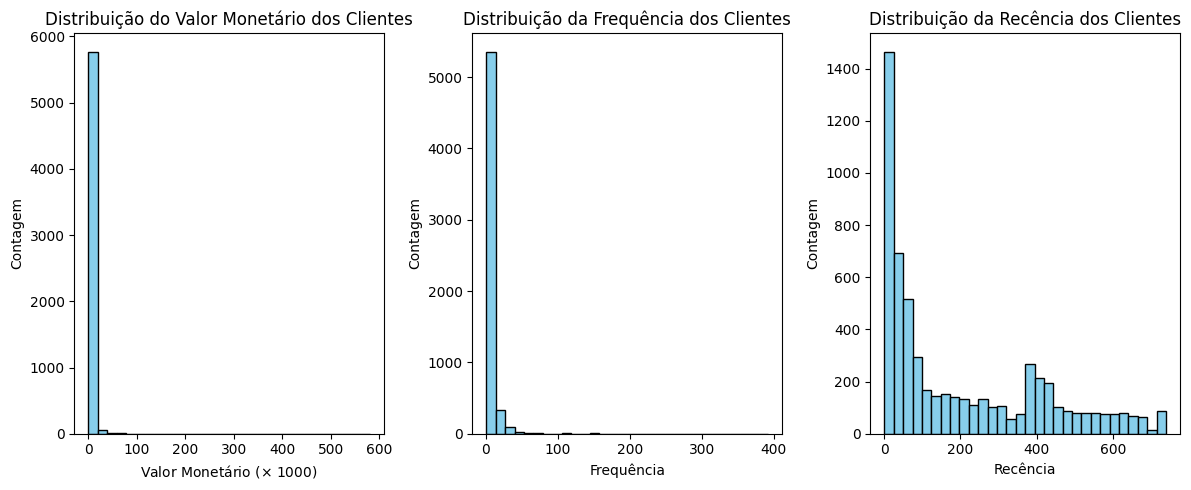

In [25]:
# Histogramas de distribuição de cada um dos fatores analisados
fig = plt.figure(figsize=(12, 5))

# Valor monetário
ax1 = fig.add_subplot(131)
ax1.hist(aggregated_df["MonetaryValue"]/1000, bins=30, color="skyblue", edgecolor="black")
ax1.set_title("Distribuição do Valor Monetário dos Clientes")
ax1.set_xlabel(r"Valor Monetário ($\times$ 1000)")
ax1.set_ylabel("Contagem")

# Frequência
ax2 = fig.add_subplot(132)
ax2.hist(aggregated_df["Frequency"], bins=30, color="skyblue", edgecolor="black")
ax2.set_title("Distribuição da Frequência dos Clientes")
ax2.set_xlabel("Frequência")
ax2.set_ylabel("Contagem")

# Recência
ax3 = fig.add_subplot(133)
ax3.hist(aggregated_df["Recency"], bins=30, color="skyblue", edgecolor="black")
ax3.set_title("Distribuição da Recência dos Clientes")
ax3.set_xlabel("Recência")
ax3.set_ylabel("Contagem")

fig.tight_layout()
plt.show()

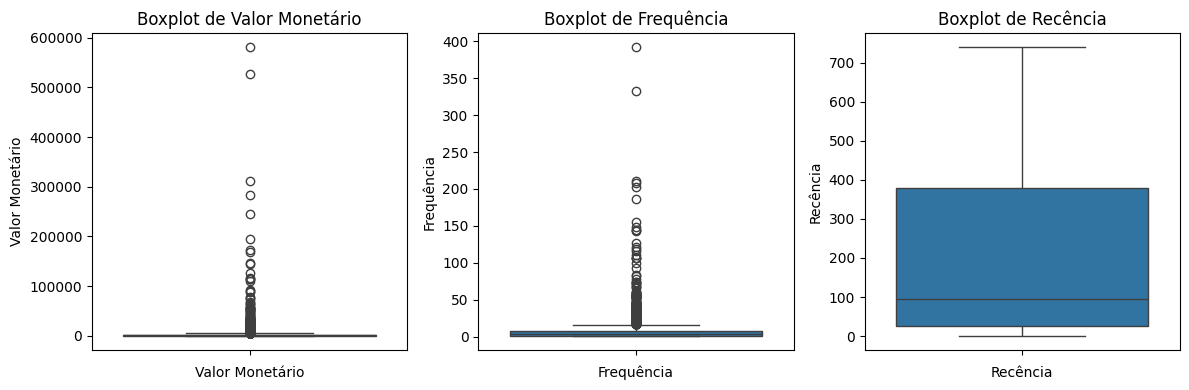

In [26]:
fig = plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(131)
sns.boxplot(aggregated_df["MonetaryValue"])
ax1.set_title("Boxplot de Valor Monetário")
ax1.set_xlabel("Valor Monetário")
ax1.set_ylabel("Valor Monetário")

ax2 = fig.add_subplot(132)
sns.boxplot(aggregated_df["Frequency"])
ax2.set_title("Boxplot de Frequência")
ax2.set_xlabel("Frequência")
ax2.set_ylabel("Frequência")

ax3 = fig.add_subplot(133)
sns.boxplot(aggregated_df["Recency"])
ax3.set_title("Boxplot de Recência")
ax3.set_xlabel("Recência")
ax3.set_ylabel("Recência")

fig.tight_layout()

Observamos que as variáveis Valor Monetário e Frequência apresentam uma quantidade significativa de valores extremos (outliers), que poderiam distorcer o resultado da clusterização. No entanto, esses registros correspondem justamente a alguns dos clientes mais relevantes para a loja, caracterizados por elevado volume de compras, alto valor monetário ou pela combinação de ambos. Por esse motivo, em vez de simplesmente removê-los da análise, optamos por separá-los e analisá-los como grupos específicos. Por fim, vamos aplicar a clusterização aos demais clientes, cuja a distribuição apresenta menor influência de valores extremos.

In [27]:
# Separando os outliers de valor monetário
MV_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
MV_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
MV_IQR = MV_Q3 - MV_Q1

MV_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > MV_Q3 + 1.5* MV_IQR)]

MV_outliers_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,626.00,626.00,626,626.00
mean,17922.09,25.95,2011-10-18 05:38:17.539936,52.82
min,5114.23,1.00,2010-01-17 11:33:00,1.00
25%,6424.36,12.00,2011-10-21 10:51:15,5.00
50%,8856.53,18.00,2011-11-23 10:35:00,17.00
75%,14114.06,29.00,2011-12-05 04:49:45,50.00
max,580987.04,392.00,2011-12-09 12:49:00,692.00
std,40962.58,31.63,NaN,104.36


In [28]:
# Separando so outliers de frequência
F_Q1 = aggregated_df["Frequency"].quantile(0.25)
F_Q3 = aggregated_df["Frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1

F_outliers_df = aggregated_df[(aggregated_df["Frequency"] > F_Q3 + 1.5* F_IQR)]

F_outliers_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,425.00,425.00,425,425.00
mean,20750.15,35.00,2011-11-08 17:45:21.458823,31.31
min,1807.44,17.00,2010-05-12 16:51:00,1.00
25%,6221.02,20.00,2011-11-14 16:59:00,4.00
50%,9555.71,25.00,2011-11-30 11:24:00,10.00
75%,16498.97,35.00,2011-12-06 12:50:00,25.00
max,580987.04,392.00,2011-12-09 12:49:00,576.00
std,48583.97,35.39,NaN,68.94


In [29]:
# Separando os dados restantes, que serão utilizados na análise de clusterização
non_outlier_df = aggregated_df[~(aggregated_df.index.isin(MV_outliers_df.index)) & ~(aggregated_df.index.isin(F_outliers_df.index))]

non_outlier_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,5178.00,5178.00,5178,5178.00
mean,1111.90,3.69,2011-05-03 13:47:08.412514,220.43
min,2.95,1.00,2009-12-01 10:49:00,1.00
25%,307.96,1.00,2010-11-10 16:44:00,33.00
50%,701.79,3.00,2011-07-27 08:48:00,136.00
75%,1547.40,5.00,2011-11-06 13:25:15,394.00
max,5087.86,16.00,2011-12-09 12:50:00,739.00
std,1107.04,3.20,NaN,211.22


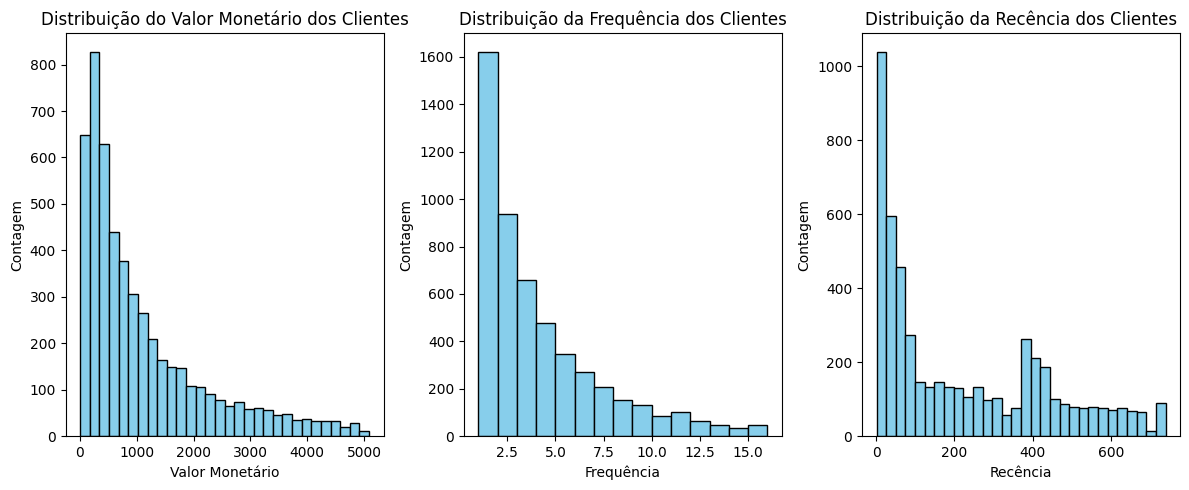

In [30]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(131)
ax1.hist(non_outlier_df["MonetaryValue"], bins=30, color="skyblue", edgecolor="black")
ax1.set_title("Distribuição do Valor Monetário dos Clientes")
ax1.set_xlabel("Valor Monetário")
ax1.set_ylabel("Contagem")

ax2 = fig.add_subplot(132)
ax2.hist(non_outlier_df["Frequency"], bins=15, color="skyblue", edgecolor="black")
ax2.set_title("Distribuição da Frequência dos Clientes")
ax2.set_xlabel("Frequência")
ax2.set_ylabel("Contagem")

ax3 = fig.add_subplot(133)
ax3.hist(non_outlier_df["Recency"], bins=30, color="skyblue", edgecolor="black")
ax3.set_title("Distribuição da Recência dos Clientes")
ax3.set_xlabel("Recência")
ax3.set_ylabel("Contagem")

fig.tight_layout()
plt.show()

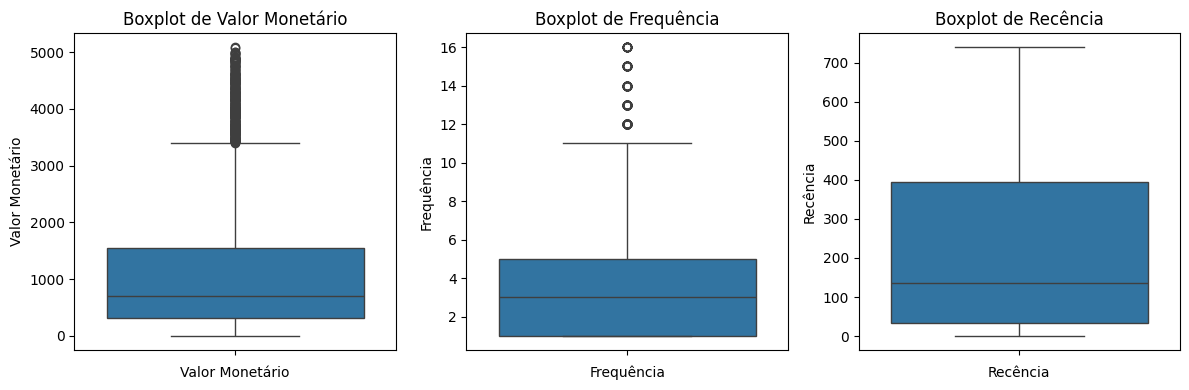

In [31]:
fig = plt.figure(figsize=(12,4))

ax1 = fig.add_subplot(131)
sns.boxplot(non_outlier_df["MonetaryValue"])
ax1.set_title("Boxplot de Valor Monetário")
ax1.set_xlabel("Valor Monetário")
ax1.set_ylabel("Valor Monetário")

ax2 = fig.add_subplot(132)
sns.boxplot(non_outlier_df["Frequency"])
ax2.set_title("Boxplot de Frequência")
ax2.set_xlabel("Frequência")
ax2.set_ylabel("Frequência")

ax3 = fig.add_subplot(133)
sns.boxplot(non_outlier_df["Recency"])
ax3.set_title("Boxplot de Recência")
ax3.set_xlabel("Recência")
ax3.set_ylabel("Recência")

fig.tight_layout()

Após a separação dos outliers, as distribuições das variáveis Valor Monetário e Frequência ainda apresentam certa assimetria positiva e caudas relativamente longas. Entretanto, a influência dos valores extremos foi consideravelmente reduzida, tornando os dados mais adequados para as etapas seguintes de preparação e clusterização.

## Clusterização
Com os dados separados e prontos para a análise, podemos seguir para o passo da clusterização.

É interessante olhar a distribuição tridimensional dos dados para uma comparação visual dos clusters depois.

Text(0.5, 0, 'Recency')

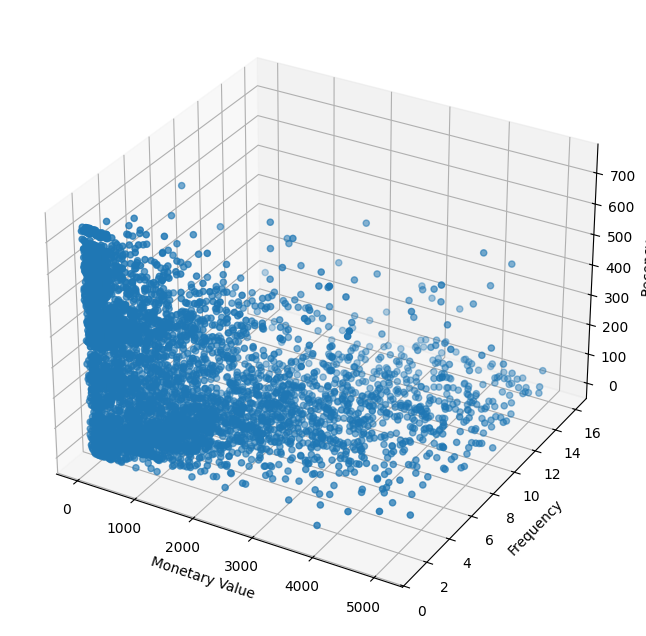

In [32]:
# Representação tridimensional dos dados
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(non_outlier_df["MonetaryValue"], non_outlier_df["Frequency"], non_outlier_df["Recency"])
ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

Antes de iniciar a clusterização, é importante garantir que as variáveis analisadas estejam em escalas comparáveis. Como o algoritmo K-Means é baseado no cálculo de distâncias, variáveis com maior amplitude podem exercer influência desproporcional sobre a formação dos clusters. Para evitar esse problema, vamos realizar a padronização das variáveis antes do ajuste do modelo.

In [33]:
# Padronização das variáveis
scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outlier_df[["MonetaryValue", "Frequency", "Recency"]])

scaled_data

array([[ 3.44160738,  1.34788805, -1.03422941],
       [ 0.49370396,  0.4091285 , -0.68859291],
       [ 2.31882885, -0.2167112 , -0.95373872],
       ...,
       [-0.66390956, -0.8425509 ,  2.08596861],
       [ 0.1215313 , -0.52963105,  1.21477523],
       [ 2.72924233,  1.0349682 , -0.8401048 ]], shape=(5178, 3))

O primeiro passo para aplicar a clusterização é determinar um número adequado de clusters para representar a estrutura dos dados. Para isso, serão utilizados o método do cotovelo e a análise de silhueta.

- Método do cotovelo: consiste em analisar a variação da inércia do K-Means em função do número de clusters. Busca-se identificar o chamado “cotovelo” do gráfico, ponto a partir do qual o aumento no número de clusters proporciona apenas pequenas reduções na inércia.
- Análise de silhueta: a pontuação de silhueta (silhouette score) avalia simultaneamente a coesão interna dos clusters e a separação entre eles. Seus valores variam de −1 a 1. Valores próximos de 1 indicam que as observações estão bem agrupadas e distantes dos clusters vizinhos, enquanto valores próximos de 0 sugerem sobreposição entre os grupos. Valores negativos podem indicar que algumas observações foram atribuídas a clusters inadequados.

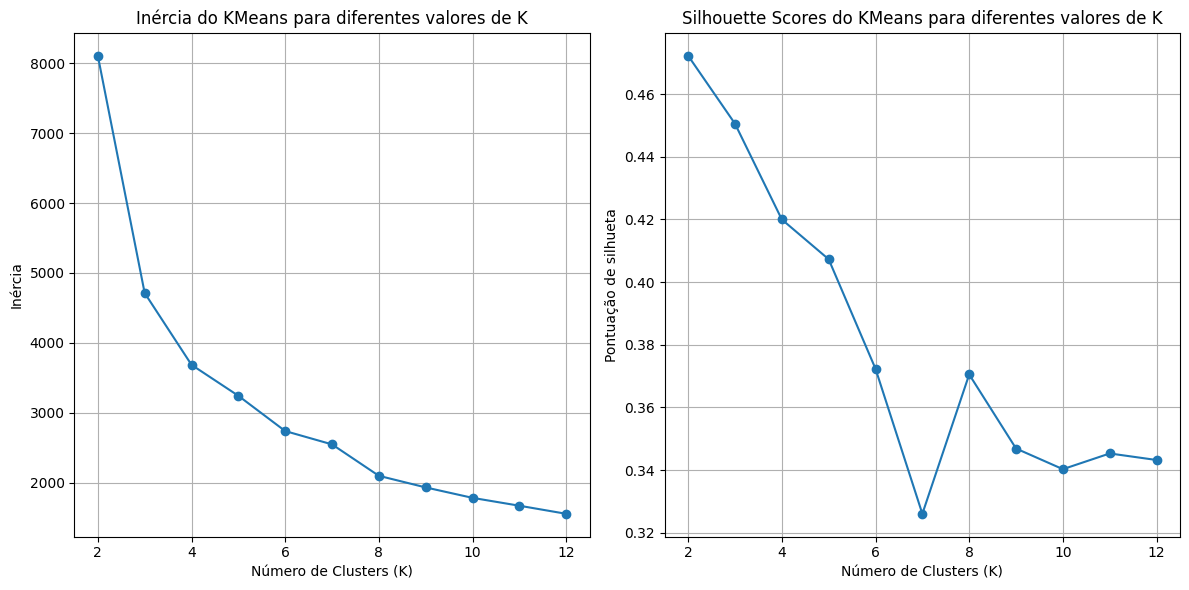

In [34]:
max_k = 12

inertia = []

silhouette_scores = []

for i in range(2, max_k+1, 1):

    kmeans = KMeans(i, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_data)

    sil_score = silhouette_score(scaled_data, cluster_labels)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(sil_score)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121)
ax1.plot(range(2, max_k+1), inertia, marker="o")
ax1.set_title("Inércia do KMeans para diferentes valores de K")
ax1.set_xlabel("Número de Clusters (K)")
ax1.set_ylabel("Inércia")
ax1.grid()

ax2 = fig.add_subplot(122)
ax2.plot(range(2, max_k+1), silhouette_scores, marker="o")
ax2.set_title("Silhouette Scores do KMeans para diferentes valores de K")
ax2.set_xlabel("Número de Clusters (K)")
ax2.set_ylabel("Pontuação de silhueta")
ax2.grid()
fig.tight_layout()
plt.show()

A partir do método do cotovelo, estima-se que o número ideal de clusters para este problema sejam 4. Além disso, a pontuação de silhueta para 4 clusters ainda indica uma separação aceitável para o problema.

Portante, vamos fazer a análise de segmentação com 4 clusters

In [35]:
# Aplicação do algoritmo KMeans sobre o conjunto de dados
kmeans = KMeans(4, random_state=42, max_iter=1000)

kmeans.fit_predict(scaled_data)

len(kmeans.labels_)

5178

Com o modelo ajustado, podemos fazer a classificação de cada cliente em um dos clusters.

In [36]:
# Registro da classificação do cluster de cada cliente na base
non_outlier_df["Cluster"] = kmeans.labels_

non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
1,12347.0,4921.53,8,2011-12-07 15:52:00,2,1
2,12348.0,1658.40,5,2011-09-25 13:13:00,75,2
3,12349.0,3678.69,3,2011-11-21 09:51:00,19,2
4,12350.0,294.40,1,2011-02-02 16:01:00,310,3
5,12351.0,300.93,1,2010-11-29 15:23:00,375,3
...,...,...,...,...,...,...
5862,18282.0,178.05,2,2011-12-02 11:43:00,8,0
5864,18284.0,411.68,1,2010-10-04 11:33:00,432,3
5865,18285.0,377.00,1,2010-02-17 10:24:00,661,3
5866,18286.0,1246.43,2,2010-08-20 11:57:00,477,3


Com os clientes devidamente classificados em seus clusters, podemos fazer uma análise descritiva de cada grupo e tirar conclusões.

Text(0.5, 0, 'Recency')

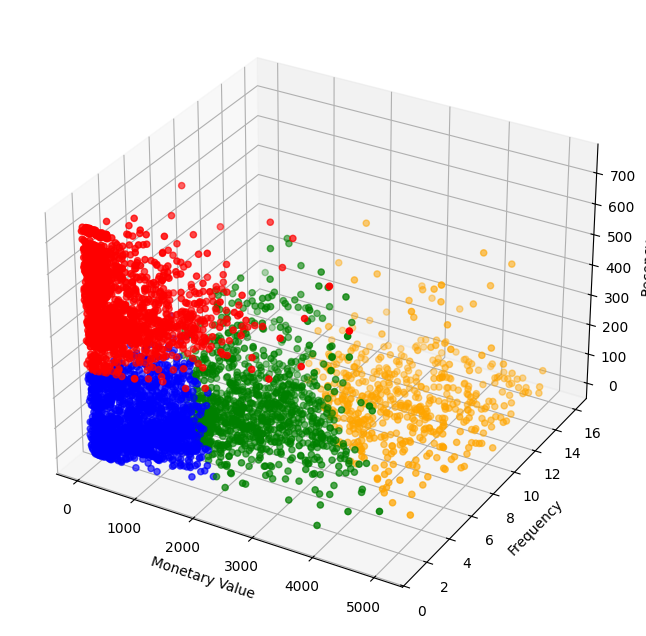

In [37]:
cluster_colors = {0: "blue",
                  1: "orange",
                  2: "green",
                  3: "red"}

colors = non_outlier_df["Cluster"].map(cluster_colors)

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
        non_outlier_df["MonetaryValue"], 
        non_outlier_df["Frequency"], 
        non_outlier_df["Recency"],
        c=colors,
        marker="o")
ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

#ax.view_init(70, 50)

In [38]:
non_outlier_df.groupby(["Cluster"]).describe()

MonetaryValue                                            \
                       count                 mean                  min   
Cluster                                                                  
0                    1888.00               577.75                 6.20   
1                     534.00              3488.06              1551.04   
2                    1071.00              1855.09               167.42   
3                    1685.00               485.00                 2.95   

                                                                        \
                         25%                  50%                  75%   
Cluster                                                                  
0                     286.72               502.66               802.02   
1                    2825.53              3469.39              4181.14   
2                    1330.67              1747.54              2247.51   
3                     176.90               331.35               627.82   

                                                             Frequency  \
                         max                  std                count   
Cluster                                                                  
0                    2033.10               372.72              1888.00   
1                    5087.86               836.60               534.00   
2                    4873.81               708.84              1071.00   
3                    4376.25               465.12              1685.00   

                                                                        \
                        mean                  min                  25%   
Cluster                                                                  
0                       2.24                 1.00                 1.00   
1                      10.57                 3.00                 9.00   
2                       5.90                 1.00                 5.00   
3                       1.74                 1.00                 1.00   

                                                                        \
                         50%                  75%                  max   
Cluster                                                                  
0                       2.00                 3.00                 6.00   
1                      11.00                12.00                16.00   
2                       6.00                 7.00                15.00   
3                       1.00                 2.00                 9.00   

                             LastInvoiceDate                              \
                         std           count                        mean   
Cluster                                                                    
0                       1.14            1888  2011-09-03 20:14:26.154661   
1                       2.67             534  2011-10-12 01:26:30.337078   
2                       1.84            1071  2011-08-29 09:33:25.266106   
3                       1.12            1685  2010-08-12 09:18:25.602374   

                                                                        \
                         min                  25%                  50%   
Cluster                                                                  
0        2011-02-02 14:25:00  2011-06-30 04:54:15  2011-10-06 11:15:30   
1        2010-05-12 13:08:00  2011-10-04 14:52:45  2011-11-10 18:52:30   
2        2010-04-27 13:06:00  2011-07-17 14:33:30  2011-10-13 16:24:00   
3        2009-12-01 10:49:00  2010-05-09 10:38:00  2010-09-17 10:37:00   

                                                                    Recency  \
                         75%                  max  std                count   
Cluster                                                                       
0        2011-11-13 16:01:00  2011-12-09 12:50:00  NaN              1888.00   
1        2011-11-28 14:00:00  2011-12-09 12:31:00  N

Para analisar as diferenças entre os clusters, serão utilizados gráficos de violino (violin plots), que permitem comparar visualmente a distribuição das variáveis em cada grupo, incluindo sua dispersão, assimetria e concentração de valores.

Text(0.5, 1.0, 'Recência por Cluster')

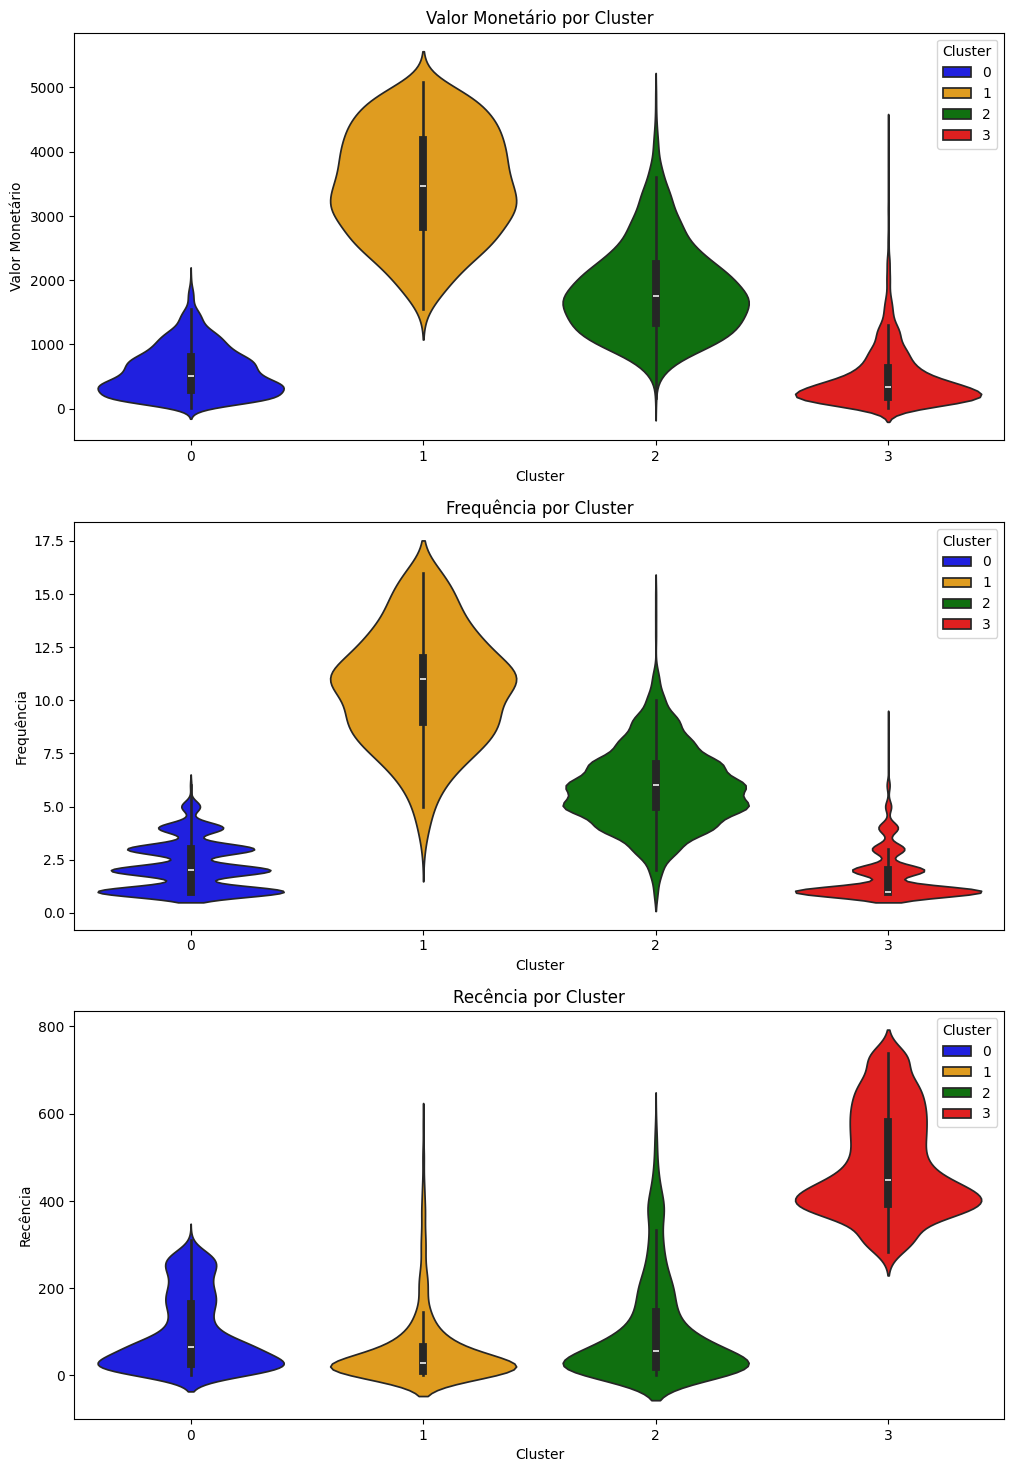

In [41]:
fig = plt.figure(figsize=(12,18))

ax1 = fig.add_subplot(311)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["MonetaryValue"], palette=cluster_colors, hue = non_outlier_df["Cluster"])

ax1.set_xlabel("Cluster")
ax1.set_ylabel("Valor Monetário")
ax1.set_title("Valor Monetário por Cluster")

ax2 = fig.add_subplot(312)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["Frequency"], palette=cluster_colors, hue = non_outlier_df["Cluster"])

ax2.set_xlabel("Cluster")
ax2.set_ylabel("Frequência")
ax2.set_title("Frequência por Cluster")

ax3 = fig.add_subplot(313)
sns.violinplot(x=non_outlier_df["Cluster"], y=non_outlier_df["Recency"], palette=cluster_colors, hue = non_outlier_df["Cluster"])

ax3.set_xlabel("Cluster")
ax3.set_ylabel("Recência")
ax3.set_title("Recência por Cluster")

In [43]:
overlap_indices = MV_outliers_df.index.intersection(F_outliers_df.index)

MV_only_outliers = MV_outliers_df.drop(overlap_indices)
F_only_outliers = F_outliers_df.drop(overlap_indices)
MV_and_F_outliers = MV_outliers_df.loc[overlap_indices]

MV_only_outliers["Cluster"] = -1
F_only_outliers["Cluster"] = -2
MV_and_F_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([MV_only_outliers, F_only_outliers, MV_and_F_outliers])
outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,77352.96,3,2011-01-18 10:01:00,326,-1
10,12356.0,5611.73,6,2011-11-17 08:40:00,23,-1
11,12357.0,17437.66,2,2011-11-06 16:07:00,33,-1
13,12359.0,8873.39,10,2011-10-13 12:47:00,58,-1
32,12378.0,5416.32,2,2011-08-02 10:34:00,130,-1
...,...,...,...,...,...,...
5806,18226.0,11878.88,26,2011-10-26 13:36:00,44,-3
5809,18229.0,10150.51,28,2011-11-28 09:48:00,12,-3
5811,18231.0,6854.17,28,2011-05-31 14:18:00,192,-3
5825,18245.0,6324.98,20,2011-12-02 14:48:00,7,-3


In [44]:
outlier_clusters_df.groupby(["Cluster"]).describe()

MonetaryValue                                            \
                       count                 mean                  min   
Cluster                                                                  
-3                    361.00             23753.83              5115.76   
-2                     64.00              3807.52              1807.44   
-1                    265.00              9977.72              5114.23   

                                                                        \
                         25%                  50%                  75%   
Cluster                                                                  
-3                   7623.79             11097.43             18046.75   
-2                   2993.29              3925.44              4530.72   
-1                   5834.59              6995.36              9903.24   

                                                             Frequency  \
                         max                  std                count   
Cluster                                                                  
-3                 580987.04             52151.84               361.00   
-2                   5088.29               879.47                64.00   
-1                 168472.50             12396.92               265.00   

                                                                        \
                        mean                  min                  25%   
Cluster                                                                  
-3                     37.30                17.00                20.00   
-2                     22.05                17.00                18.00   
-1                     10.48                 1.00                 8.00   

                                                                        \
                         50%                  75%                  max   
Cluster                                                                  
-3                     27.00                38.00               392.00   
-2                     20.00                24.00               100.00   
-1                     11.00                13.00                16.00   

                             LastInvoiceDate                              \
                         std           count                        mean   
Cluster                                                                    
-3                     37.69             361  2011-11-11 08:40:46.038781   
-2                     10.56              64  2011-10-24 22:49:41.250000   
-1                      3.88             265  2011-09-15 08:49:51.849056   

                                                                        \
                         min                  25%                  50%   
Cluster                                                                  
-3       2010-05-12 16:51:00  2011-11-16 13:21:00  2011-11-30 15:31:00   
-2       2010-10-11 12:06:00  2011-10-27 02:57:00  2011-11-23 03:08:30   
-1       2010-01-17 11:33:00  2011-09-18 15:21:00  2011-11-03 12:45:00   

                                                                    Recency  \
                         75%                  max  std                count   
Cluster                                                                       
-3       2011-12-07 08:03:00  2011-12-09 12:49:00  NaN               361.00   
-2       2011-12-05 10:58:45  2011-12-09 11:56:00  NaN                64.00   
-1       2011-11-24 12:27:00  2011-12-09 10:02:00  NaN               265.00   

                                                                        \
                        mean                  min                  25%   
Cluster                                                                  
-3                     28.70                 1.00                 3.00   
-2                     46.03                 1.00                 4.75   
-1                     85.67               

Text(0.5, 1.0, 'Recência por Cluster')

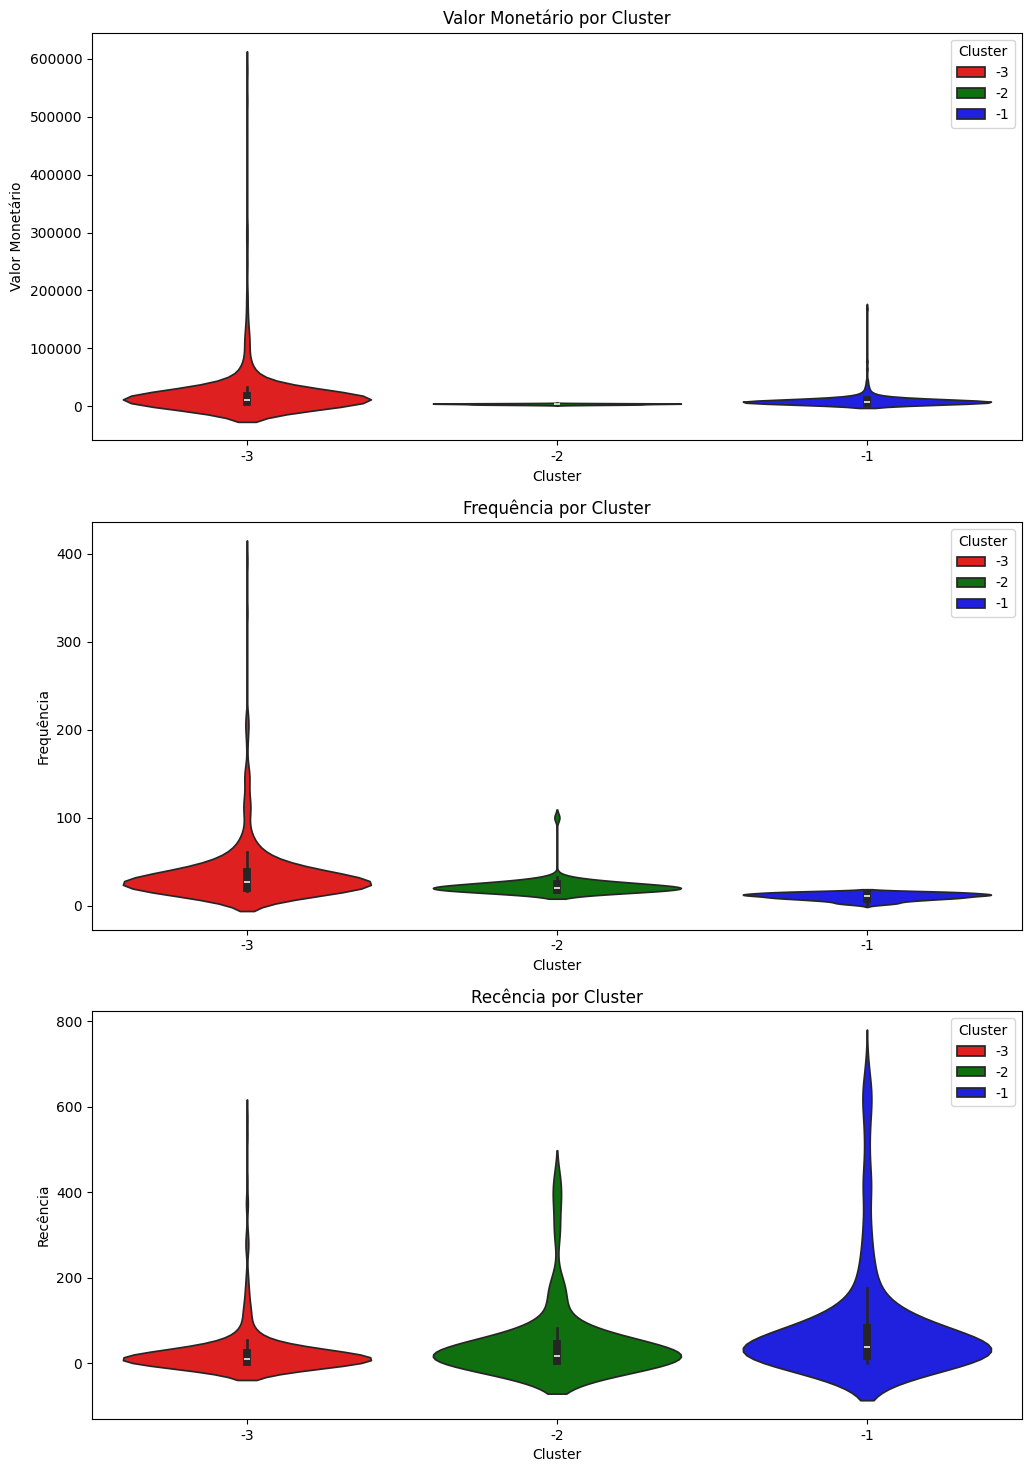

In [45]:
cluster_colors = {-1: "blue",
                  -2: "green",
                  -3: "red"}

colors = outlier_clusters_df["Cluster"].map(cluster_colors)

fig = plt.figure(figsize=(12,18))

ax1 = fig.add_subplot(311)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["MonetaryValue"], palette=cluster_colors, hue = outlier_clusters_df["Cluster"])

ax1.set_xlabel("Cluster")
ax1.set_ylabel("Valor Monetário")
ax1.set_title("Valor Monetário por Cluster")

ax2 = fig.add_subplot(312)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["Frequency"], palette=cluster_colors, hue = outlier_clusters_df["Cluster"])

ax2.set_xlabel("Cluster")
ax2.set_ylabel("Frequência")
ax2.set_title("Frequência por Cluster")

ax3 = fig.add_subplot(313)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["Recency"], palette=cluster_colors, hue = outlier_clusters_df["Cluster"])

ax3.set_xlabel("Cluster")
ax3.set_ylabel("Recência")
ax3.set_title("Recência por Cluster")

In [46]:
outlier_clusters_df.groupby(["Cluster"]).describe()

MonetaryValue                                            \
                       count                 mean                  min   
Cluster                                                                  
-3                    361.00             23753.83              5115.76   
-2                     64.00              3807.52              1807.44   
-1                    265.00              9977.72              5114.23   

                                                                        \
                         25%                  50%                  75%   
Cluster                                                                  
-3                   7623.79             11097.43             18046.75   
-2                   2993.29              3925.44              4530.72   
-1                   5834.59              6995.36              9903.24   

                                                             Frequency  \
                         max                  std                count   
Cluster                                                                  
-3                 580987.04             52151.84               361.00   
-2                   5088.29               879.47                64.00   
-1                 168472.50             12396.92               265.00   

                                                                        \
                        mean                  min                  25%   
Cluster                                                                  
-3                     37.30                17.00                20.00   
-2                     22.05                17.00                18.00   
-1                     10.48                 1.00                 8.00   

                                                                        \
                         50%                  75%                  max   
Cluster                                                                  
-3                     27.00                38.00               392.00   
-2                     20.00                24.00               100.00   
-1                     11.00                13.00                16.00   

                             LastInvoiceDate                              \
                         std           count                        mean   
Cluster                                                                    
-3                     37.69             361  2011-11-11 08:40:46.038781   
-2                     10.56              64  2011-10-24 22:49:41.250000   
-1                      3.88             265  2011-09-15 08:49:51.849056   

                                                                        \
                         min                  25%                  50%   
Cluster                                                                  
-3       2010-05-12 16:51:00  2011-11-16 13:21:00  2011-11-30 15:31:00   
-2       2010-10-11 12:06:00  2011-10-27 02:57:00  2011-11-23 03:08:30   
-1       2010-01-17 11:33:00  2011-09-18 15:21:00  2011-11-03 12:45:00   

                                                                    Recency  \
                         75%                  max  std                count   
Cluster                                                                       
-3       2011-12-07 08:03:00  2011-12-09 12:49:00  NaN               361.00   
-2       2011-12-05 10:58:45  2011-12-09 11:56:00  NaN                64.00   
-1       2011-11-24 12:27:00  2011-12-09 10:02:00  NaN               265.00   

                                                                        \
                        mean                  min                  25%   
Cluster                                                                  
-3                     28.70                 1.00                 3.00   
-2                     46.03                 1.00                 4.75   
-1                     85.67               

Observações:

| Cluster | Valor Monetário | Frequência | Recência    |        Nome         |
| :-----: | :-------------: | :--------: | :------:    |       :----:        |
|    0    |      Baixo      |    Baixa   | Recente     |  Baixo Engajamento  |
|    1    |      Alto       |    Alta    | Recente     |        Leais        |
|    2    |      Alto       |    Média   | Recente     |    Alto Potencial   |
|    3    |      Baixo      |    Baixa   | Não recente |       Inativos      |
|   -1    |   Muito Alto    |    Alta    | Recente     | Grandes Compradores |
|   -2    |      Alto       | Muito Alta | Recente     |   Super Frequentes  |
|   -3    |   Muito Alto    | Muito Alta | Recente     |       Campeões      |

Com base nas observações, podemos classificar cada segmento da seguinte forma
| Cluster |        Nome         |      Interpretação     |      Ações Sugeridas     |
| :-----: |       :----:        |      :-----------      |     :--------------      |
|    0    |  Baixo Engajamento  | Compraram recentemente, mas gastaram pouco e com pouca frequência. Podem ser clientes novos ou ocasionais | Incentivar a segunda compra, oferecer recomendações de produtos complementares usar cupons com prazo curto e investigar quais canais trouxeram esses clientes. |
|    1    |        Leais        | Compram com frequência, gastam bastante e continuam ativos. São clientes de uma base sólida e recorrente | Priorizar retenção. Oferecer programa de fidelidade, benefícios exclusivos e campanhas de cross-sell. |
|    2    |    Alto Potencial   | Apresentam gasto elevado, mas frequência intermediária. Podem evoluir para clientes leais ou VIP. | Aumentar a frequência de compra. Enviar lembretes no intervalo esperado entre compras, criar combos e assinaturas, oferecer vantagens progressivas e recomendar produtos com base no histórico. |
|    3    |       Inativos      | Compraram pouco, gastaram pouco e não retornam há algum tempo. São clientes com menor prioridade comercial. | Realizar campanhas de reativação de baixo custo, testar um incentivo pontual, coletar feedback, reduzir investimento caso não respondam, evitar descontos excessivos para um grupo de baixo retorno esperado. | 
|   -1    | Grandes Compradores | Possuem valor monetário muito alto e frequência elevada, mas não extrema. Provavelmente são clientes que realizam compras de maior ticket médio. | Oferecer atendimento personalizado, benefícios premium e acompanhamento de satisfação, mas é necessário evitar promoções genéricas que reduzam desnecessariamente a margem. |
|   -2    |   Super Frequentes  | Compram com frequência excepcional e têm gasto total alto. O valor pode vir principalmente da recorrência. | Criar recompensas por recorrência, assinaturas, reposição automática, bundles e programas de pontos. É interessante analisar quais produtos sustentam a frequência e garantir disponibilidade em estoque. |
|   -3    |       Campeões      | Apresentam valor monetário e frequência excepcionalmente altos, além de compra recente. São os clientes mais importantes da base. | Tratamento VIP, atendimento prioritário, ofertas realmente exclusivas, ações de indicação, entrevistas para entender preferências, monitoramento individual de sinais de queda de atividade. |
